<a href="https://colab.research.google.com/github/THEJAASHREE/231801181-Gen-AI/blob/main/GenAI_6b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q datasets transformers torch pandas matplotlib

import os
os.makedirs('/mnt/user-data/outputs/', exist_ok=True)

print("✓ Environment ready!")

✓ Environment ready!


SIMPLIFIED LLM PROMPTING TECHNIQUES EXPERIMENT - GSM8K Dataset

[STEP 1] Loading GSM8K dataset...
✓ Successfully loaded dataset
✓ Number of questions selected: 5

[STEP 2] Loading Flan-T5 model...
Loading model: google/flan-t5-base


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✓ Model loaded successfully.

[STEP 3] Running experiment on all prompting techniques...
This may take a few minutes...

Processing sample 1/5...
  True answer: 18
  Zero-shot response: 'Janet makes 16 eggs / day * 3 days / day = 48 eggs a day. She bakes muffins for her friends 4 muffins / day * 4 days / day = 16 muffins a day. She makes 48 eggs / day * 2 eggs / day = 96 eggs a day. She makes 96 eggs / day * $2 / egg = $180 a day at the farmers' market. The final answer:' → 180 → False
  Few-shot response: 'She eats 3 eggs a day and bakes muffins for her friends every day so she eats 3 + 4 = 7 eggs a day. She sells the eggs at the farmers' market for $2 a egg so she makes 7 * 2 = $12 at the farmers' market. She makes $12 a day at the farmers' market so she makes 12 * 2 = $12 at the farmers' market.' → 12 → False
  CoT response: 'She eats 3 eggs a day and bakes muffins for her friends every day so she eats 3 + 4 = 7 eggs a day. She sells the eggs for $2 per egg so she makes 7 * 2 = $12 

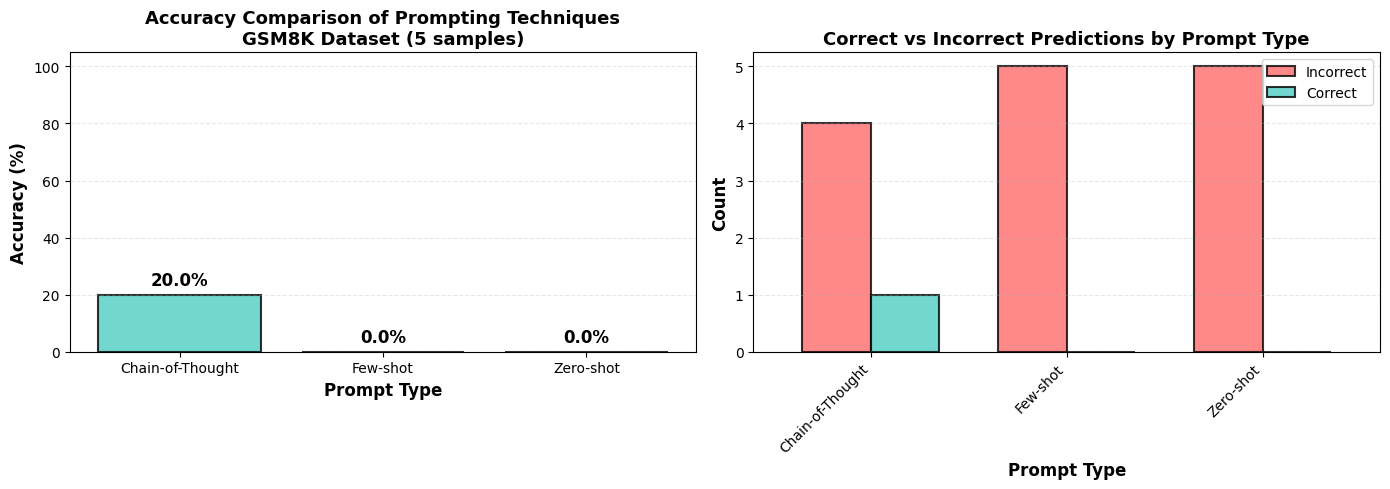

✓ Detailed results saved to: /mnt/user-data/outputs/detailed_results.csv
✓ Summary report saved to: /mnt/user-data/outputs/summary_report.txt

EXPERIMENT COMPLETE


In [3]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
import warnings
import os

warnings.filterwarnings('ignore')

print("=" * 80)
print("SIMPLIFIED LLM PROMPTING TECHNIQUES EXPERIMENT - GSM8K Dataset")
print("=" * 80)

# --- CREATE OUTPUT DIRECTORY ---
output_dir = '/mnt/user-data/outputs/'
try:
    os.makedirs(output_dir, exist_ok=True)
except:
    output_dir = './'

# --- 1. Load the GSM8K dataset ---
print("\n[STEP 1] Loading GSM8K dataset...")
try:
    dataset = load_dataset("openai/gsm8k", "main")
    samples = dataset["test"].select(range(5))
    print(f"✓ Successfully loaded dataset")
    print(f"✓ Number of questions selected: {len(samples)}")
except Exception as e:
    print(f"✗ Error loading dataset: {e}")
    exit()

# --- 2. Load the model ---
print("\n[STEP 2] Loading Flan-T5 model...")
try:
    model_name = "google/flan-t5-base"
    print(f"Loading model: {model_name}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    print("✓ Model loaded successfully.")
except Exception as e:
    print(f"✗ Error loading model: {e}")
    exit()

# --- 3. DRASTICALLY SIMPLIFIED Prompt templates ---
def zero_shot_prompt(question):
    """Zero-shot: Direct question, ask for number only"""
    return f"""{question}
Answer with only the final number, nothing else."""

def few_shot_prompt(question):
    """Few-shot: Simple examples of answers"""
    return f"""Q: Sarah has 5 apples and buys 3 more. How many total?
A: 8

Q: A book costs $10. How much for 2 books?
A: 20

Q: {question}
A:"""

def cot_prompt(question):
    """CoT: Ask for step-by-step then final number"""
    return f"""{question}

Step 1: What do we know?
Step 2: What do we need to find?
Step 3: How do we calculate it?
Step 4: The answer is:"""

# --- 4. Helper Functions ---
def get_response(prompt, max_length=150):
    """Generate response from model"""
    try:
        inputs = tokenizer(prompt, return_tensors="pt", max_length=512, truncation=True)
        outputs = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=1,
            temperature=0,
            do_sample=False
        )
        response = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
        return response
    except Exception as e:
        return None

def extract_final_number(text):
    """
    Extract ONLY the last complete number from text.
    This is the actual answer, not intermediate values.
    """
    if text is None or text == "":
        return None

    text = str(text).strip()

    # Find ALL numbers
    all_numbers = re.findall(r'-?\d+\.?\d*', text.replace(",", ""))

    if all_numbers:
        # Return the ABSOLUTE LAST number
        last = all_numbers[-1]
        try:
            return int(last) if '.' not in last else float(last)
        except:
            return None

    return None

def compare_answers(true_answer, predicted_answer):
    """Check if answers match"""
    if true_answer is None or predicted_answer is None:
        return False

    try:
        true = float(true_answer)
        pred = float(predicted_answer)

        # Exact match only
        return abs(true - pred) < 0.01
    except:
        return False

# --- 5. Extract TRUE ANSWERS from dataset more carefully ---
def extract_true_answer(answer_text):
    """
    GSM8K format: "... #### FINAL_NUMBER"
    Extract the number after ####
    """
    if not answer_text:
        return None

    # Look for #### marker
    if "####" in answer_text:
        after_marker = answer_text.split("####")[-1].strip()
        numbers = re.findall(r'-?\d+\.?\d*', after_marker.replace(",", ""))
        if numbers:
            try:
                return int(numbers[0]) if '.' not in numbers[0] else float(numbers[0])
            except:
                return None

    # Fallback: get last number
    numbers = re.findall(r'-?\d+\.?\d*', answer_text.replace(",", ""))
    if numbers:
        try:
            return int(numbers[-1]) if '.' not in numbers[-1] else float(numbers[-1])
        except:
            return None

    return None

# --- 6. Run the experiment ---
print("\n[STEP 3] Running experiment on all prompting techniques...")
print("This may take a few minutes...\n")

results = []
total_samples = len(samples)

for i, sample in enumerate(samples):
    print(f"Processing sample {i+1}/{total_samples}...")

    question = sample["question"]
    true_answer_text = sample["answer"]

    # Extract the final numeric answer from dataset
    true_answer = extract_true_answer(true_answer_text)

    if true_answer is None:
        print(f"  ⚠️ Could not extract true answer")
        continue

    print(f"  True answer: {true_answer}")

    # --- Zero-shot ---
    z_prompt = zero_shot_prompt(question)
    z_response = get_response(z_prompt, max_length=100)
    z_pred = extract_final_number(z_response) if z_response else None
    z_correct = compare_answers(true_answer, z_pred)

    print(f"  Zero-shot response: '{z_response}' → {z_pred} → {z_correct}")

    results.append({
        "sample_id": i + 1,
        "question": question[:60],
        "prompt_type": "Zero-shot",
        "model_response": z_response,
        "true_answer": true_answer,
        "predicted_answer": z_pred,
        "is_correct": z_correct
    })

    # --- Few-shot ---
    f_prompt = few_shot_prompt(question)
    f_response = get_response(f_prompt, max_length=150)
    f_pred = extract_final_number(f_response) if f_response else None
    f_correct = compare_answers(true_answer, f_pred)

    print(f"  Few-shot response: '{f_response}' → {f_pred} → {f_correct}")

    results.append({
        "sample_id": i + 1,
        "question": question[:60],
        "prompt_type": "Few-shot",
        "model_response": f_response,
        "true_answer": true_answer,
        "predicted_answer": f_pred,
        "is_correct": f_correct
    })

    # --- Chain-of-Thought ---
    c_prompt = cot_prompt(question)
    c_response = get_response(c_prompt, max_length=200)
    c_pred = extract_final_number(c_response) if c_response else None
    c_correct = compare_answers(true_answer, c_pred)

    print(f"  CoT response: '{c_response}' → {c_pred} → {c_correct}")
    print()

    results.append({
        "sample_id": i + 1,
        "question": question[:60],
        "prompt_type": "Chain-of-Thought",
        "model_response": c_response,
        "true_answer": true_answer,
        "predicted_answer": c_pred,
        "is_correct": c_correct
    })

if len(results) == 0:
    print("\n✗ No results generated.")
    exit()

print(f"\n✓ Experiment completed. Generated {len(results)} predictions.")

# --- 7. Results Analysis ---
print("\n[STEP 4] Analyzing results...")
print("=" * 80)

df = pd.DataFrame(results)

# Display detailed results
print("\n--- DETAILED RESULTS ---\n")
display_df = df[["sample_id", "prompt_type", "true_answer", "predicted_answer", "is_correct"]].copy()
display_df.columns = ["Sample", "Prompt Type", "True Answer", "Predicted", "Correct"]
print(display_df.to_string(index=False))

# Calculate accuracy by prompt type
print("\n\n--- ACCURACY SUMMARY ---\n")
accuracy_table = df.groupby("prompt_type")["is_correct"].agg(['sum', 'count']).reset_index()
accuracy_table.columns = ["Prompt Type", "Correct Count", "Total Count"]
accuracy_table["Accuracy (%)"] = (accuracy_table["Correct Count"] / accuracy_table["Total Count"] * 100).round(1)
accuracy_table = accuracy_table.sort_values("Accuracy (%)", ascending=False)

print(accuracy_table[["Prompt Type", "Correct Count", "Total Count", "Accuracy (%)"]].to_string(index=False))

# Calculate overall statistics
print("\n\n--- OVERALL STATISTICS ---")
print(f"Total questions tested: {len(samples)}")
print(f"Total predictions: {len(df)}")
print(f"Overall accuracy: {df['is_correct'].mean() * 100:.1f}%")
print(f"Overall correct: {df['is_correct'].sum()}/{len(df)}")

# Best performing method
best_idx = accuracy_table["Accuracy (%)"].idxmax()
best_method = accuracy_table.iloc[best_idx]
print(f"\nBest performing method: {best_method['Prompt Type']} ({best_method['Accuracy (%)']:.1f}%)")

# --- 8. Plot accuracy graph ---
print("\n[STEP 5] Creating visualization...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Accuracy by prompt type
colors = ['#4ECDC4', '#FF9999', '#99FF99']
accuracy_data = accuracy_table[["Prompt Type", "Accuracy (%)"]].copy()

bars = ax1.bar(accuracy_data["Prompt Type"], accuracy_data["Accuracy (%)"],
               color=colors[:len(accuracy_data)], edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_xlabel("Prompt Type", fontsize=12, fontweight='bold')
ax1.set_ylabel("Accuracy (%)", fontsize=12, fontweight='bold')
ax1.set_title("Accuracy Comparison of Prompting Techniques\nGSM8K Dataset (5 samples)",
              fontsize=13, fontweight='bold')
ax1.set_ylim(0, 105)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add percentage labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{height:.1f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# Chart 2: Correct/Incorrect distribution
results_by_type = df.groupby("prompt_type")["is_correct"].value_counts().unstack(fill_value=0)

if len(accuracy_data) > 0:
    prompt_order = accuracy_data["Prompt Type"].tolist()
    if set(prompt_order).issubset(results_by_type.index):
        results_by_type = results_by_type.loc[prompt_order]

results_by_type.plot(kind='bar', ax=ax2, color=['#FF6B6B', '#4ECDC4'],
                     edgecolor='black', linewidth=1.5, alpha=0.8, width=0.7)
ax2.set_xlabel("Prompt Type", fontsize=12, fontweight='bold')
ax2.set_ylabel("Count", fontsize=12, fontweight='bold')
ax2.set_title("Correct vs Incorrect Predictions by Prompt Type", fontsize=13, fontweight='bold')
ax2.legend(['Incorrect', 'Correct'], loc='upper right', fontsize=10)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()

# Save graph
try:
    graph_path = os.path.join(output_dir, 'prompting_accuracy_comparison.png')
    plt.savefig(graph_path, dpi=300, bbox_inches='tight')
    print(f"✓ Graph saved to: {graph_path}")
except Exception as e:
    print(f"⚠ Could not save graph: {e}")

plt.show()

# --- 9. Save detailed results to CSV ---
try:
    csv_path = os.path.join(output_dir, 'detailed_results.csv')
    df.to_csv(csv_path, index=False)
    print(f"✓ Detailed results saved to: {csv_path}")
except Exception as e:
    print(f"⚠ Could not save CSV: {e}")

# --- 10. Save summary report ---
try:
    summary_path = os.path.join(output_dir, 'summary_report.txt')
    with open(summary_path, 'w') as f:
        f.write("=" * 80 + "\n")
        f.write("LLM PROMPTING TECHNIQUES EXPERIMENT SUMMARY\n")
        f.write("=" * 80 + "\n\n")
        f.write("ACCURACY SUMMARY\n")
        f.write("-" * 80 + "\n")
        f.write(accuracy_table[["Prompt Type", "Correct Count", "Total Count", "Accuracy (%)"]].to_string(index=False))
        f.write(f"\n\nOVERALL STATISTICS\n")
        f.write("-" * 80 + "\n")
        f.write(f"Total questions tested: {len(samples)}\n")
        f.write(f"Total predictions: {len(df)}\n")
        f.write(f"Overall accuracy: {df['is_correct'].mean() * 100:.1f}%\n")
        f.write(f"Best performing method: {best_method['Prompt Type']} ({best_method['Accuracy (%)']:.1f}%)\n")
    print(f"✓ Summary report saved to: {summary_path}")
except Exception as e:
    print(f"⚠ Could not save summary: {e}")

print("\n" + "=" * 80)
print("EXPERIMENT COMPLETE")
print("=" * 80)